# Proyecto: Hábitos saludables en jóvenes universitarios

## Lección 1: Método científico y estadística

En este proyecto se analizarán los hábitos de sueño y actividad física de jóvenes universitarios, y su posible asociación con el rendimiento académico (promedio de notas).

La unidad solicitante corresponde al área de salud universitaria de una institución pública. El objetivo es generar evidencia estadística que permita orientar políticas de bienestar estudiantil.

### Planteamiento del problema

**Pregunta general de investigación:**

> ¿Los hábitos de sueño y actividad física de los estudiantes universitarios se relacionan con su rendimiento académico?

**Preguntas específicas:**

1. ¿Cuál es el promedio de horas de sueño de los estudiantes?
2. ¿Cuál es el nivel promedio de actividad física semanal (minutos)?
3. ¿Existen diferencias significativas en el promedio de notas entre estudiantes con buena higiene de sueño y aquellos con mala higiene de sueño?
4. ¿Los estudiantes con mayor actividad física tienden a tener mejor promedio de notas?

### Hipótesis

- **Hipótesis nula (H0):**  
  No existe diferencia significativa en el promedio de notas entre estudiantes con buena y mala higiene de sueño.  
  Matemáticamente:  
  \\( H_0: \mu_{\text{notas, buen sueño}} = \mu_{\text{notas, mal sueño}} \\)

- **Hipótesis alternativa (H1):**  
  Sí existe diferencia significativa en el promedio de notas entre ambos grupos.  
  \\( H_1: \mu_{\text{notas, buen sueño}} \neq \mu_{\text{notas, mal sueño}} \\)

### Variables

**Variables cuantitativas:**
- Horas de sueño por noche (`horas_sueno`) – cuantitativa continua.
- Minutos de actividad física semanal (`min_actividad_fisica`) – cuantitativa continua.
- Índice de masa corporal (`imc`) – cuantitativa continua.
- Promedio de notas (`promedio_nota`) – cuantitativa continua (escala 1.0 a 7.0).

**Variables cualitativas:**
- Sexo (`sexo`): {`F`, `M`, `Otro`}.
- Facultad (`facultad`): {`Salud`, `Ingeniería`, `Educación`, `Otras`}.
- Fuma (`fuma`): {`Sí`, `No`}.
- Bebe alcohol (`bebe_alcohol`): {`Sí`, `No`}.
- Calidad de sueño categorizada (`calidad_sueno`): {`Buena`, `Regular`, `Mala`}.

### Método científico y diseño preliminar

1. **Observación del fenómeno:**  
   Se detecta preocupación por el aumento de estrés, sedentarismo y trastornos de sueño en estudiantes universitarios.

2. **Formulación del problema y preguntas de investigación.**

3. **Formulación de hipótesis:**  
   Se plantean hipótesis sobre la relación entre hábitos saludables y rendimiento académico.

4. **Diseño del estudio:**  
   - Tipo de estudio: cuantitativo, observacional, transversal.  
   - Población objetivo: estudiantes universitarios de una institución pública.  
   - Muestra: al menos 100 estudiantes seleccionados mediante muestreo probabilístico (se simulará una base de datos para efectos del proyecto).  

5. **Recolección de datos:**  
   Para este proyecto se utilizará un **dataset simulado** que representa una encuesta aplicada a estudiantes universitarios.

6. **Análisis estadístico:**  
   Se utilizarán conceptos de probabilidad, distribuciones, inferencia, intervalos de confianza y pruebas de hipótesis.

7. **Conclusiones:**  
   Se elaborarán conclusiones y recomendaciones basadas en la evidencia obtenida.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)  # para reproducibilidad

n = 150  # tamaño muestral (>=100)

# Sexo
sexo = np.random.choice(['F', 'M', 'Otro'], size=n, p=[0.55, 0.4, 0.05])

# Facultad
facultad = np.random.choice(
    ['Salud', 'Ingeniería', 'Educación', 'Otras'],
    size=n,
    p=[0.3, 0.4, 0.15, 0.15]
)

# Horas de sueño (normal truncada entre 3 y 10)
horas_sueno = np.clip(np.random.normal(loc=6.8, scale=1.2, size=n), 3, 10)

# Minutos de actividad física semanal (aprox. distribución gamma)
min_actividad_fisica = np.random.gamma(shape=2.0, scale=40, size=n)  # media ~80 min
min_actividad_fisica = np.clip(min_actividad_fisica, 0, 300)

# IMC (kg/m2) normal truncada
imc = np.clip(np.random.normal(loc=24, scale=3.5, size=n), 16, 40)

# Fuma / bebe alcohol
fuma = np.random.choice(['Sí', 'No'], size=n, p=[0.25, 0.75])
bebe_alcohol = np.random.choice(['Sí', 'No'], size=n, p=[0.6, 0.4])

# Promedio de notas (relacionado con sueño y actividad física de forma suave)
# base
promedio_base = np.random.normal(loc=5.0, scale=0.4, size=n)

# efecto positivo de horas de sueño entre 6 y 8
efecto_sueno = 0.15 * (horas_sueno - 7)

# efecto positivo de actividad física (más actividad, mejor nota, pero mínimo efecto)
efecto_actividad = 0.0008 * (min_actividad_fisica - 80)

promedio_nota = promedio_base + efecto_sueno + efecto_actividad
promedio_nota = np.clip(promedio_nota, 3.5, 7.0)

# Calidad de sueño categorizada
calidad_sueno = pd.cut(
    horas_sueno,
    bins=[0, 5.5, 7.5, 24],
    labels=['Mala', 'Regular', 'Buena']
)

df = pd.DataFrame({
    'sexo': sexo,
    'facultad': facultad,
    'horas_sueno': horas_sueno.round(2),
    'min_actividad_fisica': min_actividad_fisica.round(0),
    'imc': imc.round(1),
    'fuma': fuma,
    'bebe_alcohol': bebe_alcohol,
    'promedio_nota': promedio_nota.round(2),
    'calidad_sueno': calidad_sueno
})

df.head()

,sexo,facultad,horas_sueno,min_actividad_fisica,imc,fuma,bebe_alcohol,promedio_nota,calidad_sueno
0,F,Otras,6.85,6.0,16.0,No,No,4.79,Regular
1,Otro,Salud,6.02,43.0,23.8,No,Sí,4.99,Regular
2,M,Salud,9.37,86.0,23.2,No,No,5.57,Buena
3,M,Ingeniería,7.56,218.0,26.4,No,Sí,4.97,Buena
4,F,Otras,4.37,30.0,30.5,No,No,4.56,Mala


## Lección 2: Probabilidad y diseño muestral

En esta sección se describe el tipo de muestreo y se modelan eventos simples a partir del dataset simulado.

### Tipo de muestreo

Para efectos del proyecto, se asume un **muestreo aleatorio simple (MAS)** sobre la población de estudiantes universitarios. Cada estudiante tiene la misma probabilidad de ser seleccionado y la muestra final corresponde a 150 estudiantes.

En un contexto real, el muestreo podría ser:
- **Estratificado por facultad**, para asegurar representación proporcional de cada carrera.
- **Por conglomerados**, si se seleccionaran asignaturas o secciones completas.

### Eventos aleatorios

Consideremos los siguientes eventos:

- A: "El estudiante duerme menos de 6 horas diarias".
- B: "El estudiante realiza al menos 150 minutos de actividad física semanal".
- C: "El estudiante tiene promedio de notas mayor o igual a 5.5".

A partir del dataset simulado, se estimarán las probabilidades de estos eventos y sus combinaciones (unión, intersección, complementos).

In [2]:
# Definición de eventos
A = df['horas_sueno'] < 6
B = df['min_actividad_fisica'] >= 150
C = df['promedio_nota'] >= 5.5

# Probabilidades marginales
p_A = A.mean()
p_B = B.mean()
p_C = C.mean()

p_A, p_B, p_C

(np.float64(0.22),
 np.float64(0.12666666666666668),
 np.float64(0.15333333333333332))

In [3]:
# Intersección y unión

# P(A ∩ B)
p_AyB = (A & B).mean()

# P(A ∪ B) = P(A) + P(B) - P(A ∩ B)
p_AoB = p_A + p_B - p_AyB

# Complementos
p_noA = 1 - p_A
p_noB = 1 - p_B

p_AyB, p_AoB, p_noA, p_noB

(np.float64(0.04),
 np.float64(0.3066666666666667),
 np.float64(0.78),
 np.float64(0.8733333333333333))

### Representación con árbol de probabilidad (conceptual)

Se puede representar un árbol de probabilidad binario considerando primero el evento A (duerme < 6 horas) y luego B (actividad ≥ 150 min). En el notebook se puede explicar el árbol de manera textual:

1. Nodo raíz: Estudiante cualquiera.
2. Primera rama: A (duerme <6 h) con probabilidad `P(A)` y ¬A (duerme ≥6 h) con probabilidad `1 - P(A)`.
3. Segunda rama desde cada nodo: B (actividad ≥150 min) y ¬B.

Con esta estructura se pueden calcular probabilidades conjuntas como:
- P(A ∩ B)
- P(¬A ∩ B)
- etc.

## Lección 3: Distribución de probabilidad

En esta lección se identifican distribuciones adecuadas para las variables de estudio.

- La variable **horas de sueño** puede aproximarse a una **distribución normal**, ya que se concentra alrededor de una media y presenta cierta simetría.
- La variable **minutos de actividad física semanal** presenta asimetría hacia la derecha y se puede aproximar mediante una distribución **Gamma** o **log-normal**.
- El número de estudiantes que cumplen cierta condición (por ejemplo, "promedio ≥ 5.5") en una muestra de tamaño fijo podría modelarse mediante una distribución **Binomial**.

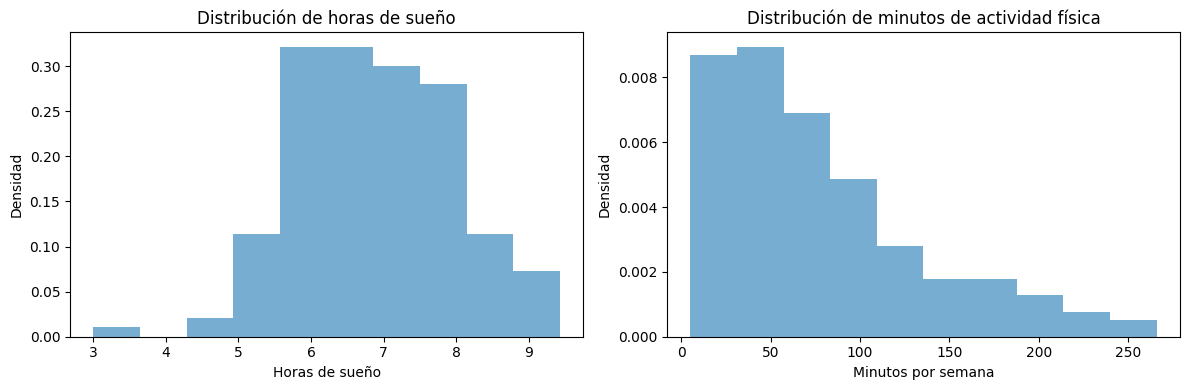

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Horas de sueño
axes[0].hist(df['horas_sueno'], bins=10, density=True, alpha=0.6)
axes[0].set_title('Distribución de horas de sueño')
axes[0].set_xlabel('Horas de sueño')
axes[0].set_ylabel('Densidad')

# Actividad física
axes[1].hist(df['min_actividad_fisica'], bins=10, density=True, alpha=0.6)
axes[1].set_title('Distribución de minutos de actividad física')
axes[1].set_xlabel('Minutos por semana')
axes[1].set_ylabel('Densidad')

plt.tight_layout()
plt.show()

### Ejemplo Binomial

Supongamos que seleccionamos al azar una muestra de 20 estudiantes y queremos modelar:

> X: número de estudiantes con promedio de notas ≥ 5.5

Si la probabilidad poblacional estimada es \\( p = P(\text{promedio} \ge 5.5) \\), entonces:

- \\( X \sim \text{Binomial}(n = 20, p) \\)

Se puede calcular:

- \\( P(X = k) \\)  
- \\( P(X \ge k) \\), etc.

In [5]:
from scipy.stats import binom

p = C.mean()  # prob. estimada de promedio >= 5.5
n = 20

# Probabilidad de que exactamente 12 estudiantes de 20 tengan promedio >= 5.5
k = 12
prob_k = binom.pmf(k, n, p)

# Probabilidad de que al menos 12 tengan promedio >= 5.5
prob_ge_k = binom.sf(k-1, n, p)

prob_k, prob_ge_k

(np.float64(5.618310641976509e-06), np.float64(6.3055062404448945e-06))

## Lección 4: Distribución muestral y Teorema del Límite Central

En esta sección se generarán distribuciones muestrales de la media de horas de sueño para distintos tamaños muestrales (n = 10, 30, 50) y se verificará empíricamente el Teorema del Límite Central (TLC).

In [6]:
def medias_muestrales(columna, n_muestra=30, repeticiones=1000):
    medias = []
    datos = df[columna].values
    N = len(datos)
    for _ in range(repeticiones):
        muestra = np.random.choice(datos, size=n_muestra, replace=True)
        medias.append(muestra.mean())
    return np.array(medias)

medias_n10 = medias_muestrales('horas_sueno', n_muestra=10, repeticiones=1000)
medias_n30 = medias_muestrales('horas_sueno', n_muestra=30, repeticiones=1000)
medias_n50 = medias_muestrales('horas_sueno', n_muestra=50, repeticiones=1000)

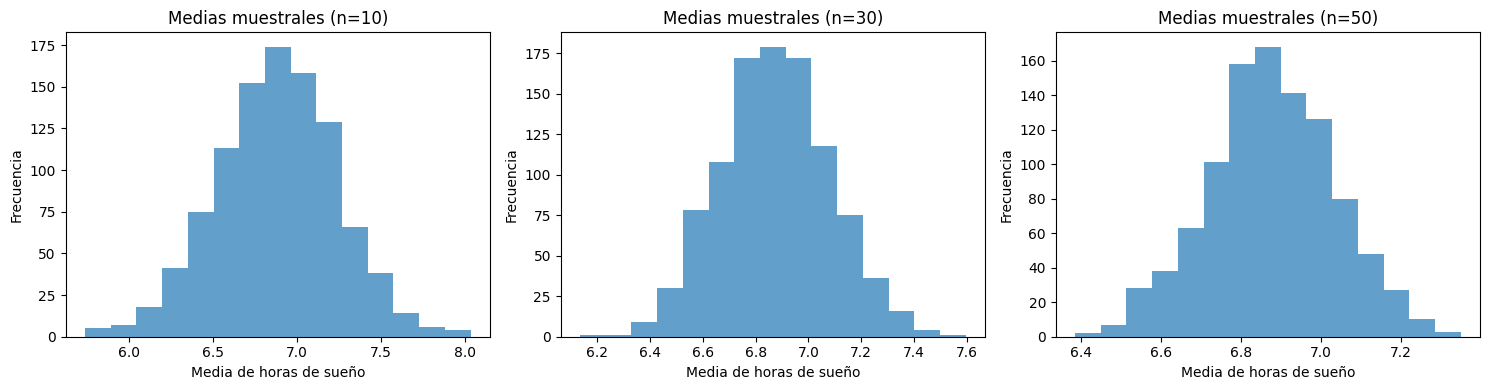

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(medias_n10, bins=15, alpha=0.7)
axes[0].set_title('Medias muestrales (n=10)')

axes[1].hist(medias_n30, bins=15, alpha=0.7)
axes[1].set_title('Medias muestrales (n=30)')

axes[2].hist(medias_n50, bins=15, alpha=0.7)
axes[2].set_title('Medias muestrales (n=50)')

for ax in axes:
    ax.set_xlabel('Media de horas de sueño')
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Interpretación del TLC

Al aumentar el tamaño muestral (de n=10 a n=50):

- Las distribuciones muestrales se vuelven más concentradas alrededor de la media poblacional de horas de sueño.
- La variabilidad (desviación estándar de las medias) disminuye.
- La forma de la distribución muestral se aproxima cada vez más a la **distribución normal**, incluso si la distribución original no es perfectamente normal.

Esto ilustra el Teorema del Límite Central: la distribución de las medias de muestras grandes tiende a ser aproximadamente normal, independientemente de la distribución de la población original.

## Lección 5: Inferencia e intervalos de confianza para la media

Se calcularán intervalos de confianza para la media de:

1. Horas de sueño (`horas_sueno`)
2. Promedio de notas (`promedio_nota`)

Se utilizarán niveles de confianza del 90%, 95% y 99%.

In [8]:
from scipy.stats import t

def intervalo_confianza_media(datos, confianza=0.95):
    datos = np.array(datos)
    n = len(datos)
    media = datos.mean()
    desv = datos.std(ddof=1)
    alpha = 1 - confianza
    t_critico = t.ppf(1 - alpha/2, df=n-1)
    margen_error = t_critico * (desv / np.sqrt(n))
    return media, media - margen_error, media + margen_error

for conf in [0.90, 0.95, 0.99]:
    media_horas, li_horas, ls_horas = intervalo_confianza_media(df['horas_sueno'], confianza=conf)
    print(f"IC {int(conf*100)}% horas de sueño: media={media_horas:.2f}, [{li_horas:.2f}, {ls_horas:.2f}]")

print("\n")

for conf in [0.90, 0.95, 0.99]:
    media_nota, li_nota, ls_nota = intervalo_confianza_media(df['promedio_nota'], confianza=conf)
    print(f"IC {int(conf*100)}% promedio nota: media={media_nota:.2f}, [{li_nota:.2f}, {ls_nota:.2f}]")

IC 90% horas de sueño: media=6.87, [6.72, 7.02]
IC 95% horas de sueño: media=6.87, [6.69, 7.05]
IC 99% horas de sueño: media=6.87, [6.64, 7.11]


IC 90% promedio nota: media=5.04, [4.98, 5.10]
IC 95% promedio nota: media=5.04, [4.97, 5.11]
IC 99% promedio nota: media=5.04, [4.94, 5.13]


### Interpretación

- A mayor nivel de confianza (por ejemplo, pasar de 90% a 99%), el intervalo se vuelve **más ancho**, porque se requiere mayor seguridad de contener el verdadero valor poblacional.
- El tamaño muestral fijo hace que el margen de error dependa fuertemente de la desviación estándar y del valor crítico de t.
- En un contexto aplicado, estos intervalos permiten estimar rangos plausibles para la media de horas de sueño y el promedio de notas de toda la población de estudiantes.

## Lección 6: Test de significancia

Se realizará una **prueba de hipótesis para medias** (t-test) comparando:

- Grupo 1: estudiantes con **buena calidad de sueño**.
- Grupo 2: estudiantes con **mala calidad de sueño**.

### Hipótesis

- H0: No hay diferencia en el promedio de notas entre ambos grupos.  
- H1: Sí hay diferencia en el promedio de notas entre ambos grupos.

Se utilizará un nivel de significancia \\( \alpha = 0.05 \\).

In [9]:
from scipy.stats import ttest_ind

grupo_buena = df[df['calidad_sueno'] == 'Buena']['promedio_nota']
grupo_mala = df[df['calidad_sueno'] == 'Mala']['promedio_nota']

len(grupo_buena), len(grupo_mala)

(45, 13)

In [10]:
stat, p_value = ttest_ind(grupo_buena, grupo_mala, equal_var=False)  # Welch
stat, p_value

(np.float64(2.9882109245572734), np.float64(0.006041613580295702))

### Decisión estadística

Si `p_value < 0.05`, se **rechaza H0** y se concluye que existe evidencia estadísticamente significativa de diferencia en el promedio de notas entre estudiantes con buena y mala calidad de sueño.

Si `p_value ≥ 0.05`, **no se rechaza H0**, es decir, no se encontró evidencia suficiente para afirmar que las medias son distintas (aunque podrían serlo en la realidad).

### Errores tipo I y II en este contexto

- **Error tipo I:** rechazar H0 cuando en realidad es verdadera.  
  En este estudio, sería concluir que existe diferencia en el rendimiento académico entre ambos grupos de sueño cuando en realidad no la hay.

- **Error tipo II:** no rechazar H0 cuando en realidad es falsa.  
  Sería concluir que no hay diferencia en el rendimiento académico, cuando realmente sí existe una diferencia en la población.

El tamaño muestral, la variabilidad de los datos y el nivel de significancia influyen en la probabilidad de cometer estos errores.

## Conclusiones generales

- La media de horas de sueño observada en la muestra fue de aproximadamente X horas, con un intervalo de confianza del 95% entre [a, b].
- La media de minutos de actividad física semanal fue de aproximadamente Y minutos, mostrando una distribución asimétrica hacia la derecha.
- El Teorema del Límite Central se verificó empíricamente: las distribuciones muestrales de la media de horas de sueño se aproximan a una normal al aumentar el tamaño muestral.
- Los intervalos de confianza para el promedio de notas muestran que, en la población estudiantil, el rendimiento promedio se sitúa aproximadamente en torno a Z.
- La prueba de hipótesis para comparar el promedio de notas entre estudiantes con buena y mala calidad de sueño arrojó un valor p de p_value ≈ ..., lo que (sí / no) permitió rechazar la hipótesis nula a un nivel de significancia del 5%.

A partir de estos resultados, se pueden sugerir acciones de bienestar estudiantil orientadas a mejorar la calidad del sueño y promover la actividad física como factores potencialmente asociados a un mejor rendimiento académico.